# import

In [2]:
import matplotlib.pyplot as plt
from cycler import cycler
import pandas as pd
from matplotlib.ticker import MultipleLocator, FuncFormatter


In [2]:
# Figure format
rc = {'axes.facecolor':'white',
      'figure.figsize': (12, 6),
      'savefig.dpi': 600,
#       'axes.grid' : False,
      'axes.edgecolor' : '0.15',
      
      'font.family':'Times New Roman',
      'font.serif': ['Times New Roman', 'Times', 'STIXGeneral'],  # 备选
      # —— 数学字体（$...$ 内）——
      'mathtext.fontset': 'stix',     # 关键：让 μ、ε 等用 STIX（Times 风格）
      'axes.unicode_minus': False,    # 让负号显示为正常的连字符


      'axes.labelsize': 20,         # X、Y 轴标题字体
      'axes.labelweight': 'bold',   # X、Y 轴标题加粗
      'xtick.labelsize': 20,        # X轴刻度文字
      'ytick.labelsize': 20,        # Y轴刻度文字
      'legend.fontsize': 20,       # 图例字体

      # 线宽与颜色顺序
      'lines.linewidth': 2.25,      # 所有线条默认 2.25 pt
      'axes.prop_cycle': cycler('color', list(('k', 'r', 'b', 'g', 'm', 'c', 'y'))),

      # 刻度朝外 & 粗细
      'xtick.direction': 'out',
      'ytick.direction': 'out',
      'xtick.major.size': 6,
      'ytick.major.size': 6,
      'xtick.major.width': 2.0,
      'ytick.major.width': 2.0,

      # 坐标轴（内框）线宽
      'axes.linewidth': 2.0,
      } 
# lack of font size
plt.rcParams.update(rc)

# pressure gauge data

## Evo5 pressure show

In [3]:
from pathlib import Path

# file_path = Path.cwd() / "1" / "1.xlsx"  # 获取当前工作目录的目录下的 "1/1.xlsx" 文件路径
# file_path = Path.cwd().parent / "1" / "1.xlsx" # 获取当前工作目录的父目录下的 "1/1.xlsx" 文件路径


example_path = Path.cwd() / "model" / "Zgabay_Evo5.xlsx"
try:
    xls = pd.ExcelFile(example_path, engine="openpyxl")
    print("Sheets:", xls.sheet_names)
except FileNotFoundError:
    print(f"找不到文件: {example_path}")
except Exception as e:
    print("读取 Excel 时出错:", e)

Sheets: ['Information', 'Signal Summary', 'Grid', 'pressure_drop', 'pressure_drop (2)']


In [4]:
# 读取指定 sheet（'pressure_drop (2)'），打印标题和列名，并将每列数据导出为 notebook 变量（变量名由列名简化而来）
sheet_name = "pressure_drop (2)"

try:
    # 读取为带列名的 DataFrame
    sheet_df = xls.parse(sheet_name)
except Exception as e:
    raise RuntimeError(f"无法读取 sheet '{sheet_name}': {e}")

# 尝试从最上方单元格判断是否存在显式的标题（例如表格上方有单独的一行标题）
_rows = xls.parse(sheet_name, header=None)
top_cell = _rows.iloc[0, 0] if not _rows.empty else None
if isinstance(top_cell, str) and top_cell.strip() and top_cell.strip() not in list(sheet_df.columns):
    sheet_title = top_cell.strip()
else:
    sheet_title = sheet_name

print("Sheet title:", sheet_title)
print("Columns:", list(sheet_df.columns))

# 将每一列导出为变量，变量名由列名规范化得到（非字母数字替换为下划线，若以数字开头则加前缀下划线）
created_vars = {}
for col in sheet_df.columns:
    # 跳过完全空的列名
    if col is None:
        continue
    name = str(col).strip()
    if not name:
        continue
    # 规范化为合法的 Python 标识符
    var_name = ''.join(ch if (ch.isalnum() or ch == "_") else "_" for ch in name)
    if var_name and var_name[0].isdigit():
        var_name = "_" + var_name
    if not var_name:
        var_name = "col"
    base = var_name
    i = 1
    # 避免覆盖已有全局变量
    while var_name in globals():
        var_name = f"{base}_{i}"
        i += 1
    # 将该列作为 pandas Series 赋值到全局命名空间
    globals()[var_name] = sheet_df[col]
    created_vars[var_name] = col

print(f"Created {len(created_vars)} variables from sheet '{sheet_name}':")
for vn, col in created_vars.items():
    print(f"  {vn}  <- column '{col}' (length={len(globals()[vn])})")

# 显示前几行作为校验
print("\nPreview (first 5 rows) of the dataframe:")
print(sheet_df.head())

Sheet title: pressure_drop (2)
Columns: ['Date-Time', 13004, 13713, 14851, 15321, 16598, 17423, 'delta_time']
Created 8 variables from sheet 'pressure_drop (2)':
  Date_Time  <- column 'Date-Time' (length=52988)
  _13004  <- column '13004' (length=52988)
  _13713  <- column '13713' (length=52988)
  _14851  <- column '14851' (length=52988)
  _15321  <- column '15321' (length=52988)
  _16598  <- column '16598' (length=52988)
  _17423  <- column '17423' (length=52988)
  delta_time  <- column 'delta_time' (length=52988)

Preview (first 5 rows) of the dataframe:
            Date-Time     13004    13713     14851     15321     16598  \
0 2022-03-15 09:00:00  0.000000  0.00000  0.000000  0.000000  0.000000   
1 2022-03-15 09:00:10  0.787000 -0.00218  0.000000  0.000000 -0.007625   
2 2022-03-15 09:00:20  0.787000 -0.00218  0.012052  0.067000 -0.012000   
3 2022-03-15 09:00:30  1.058329  0.00482  0.019000  0.067000 -0.012000   
4 2022-03-15 09:00:40  1.216000  0.00482  0.006966  0.127169 -0.00

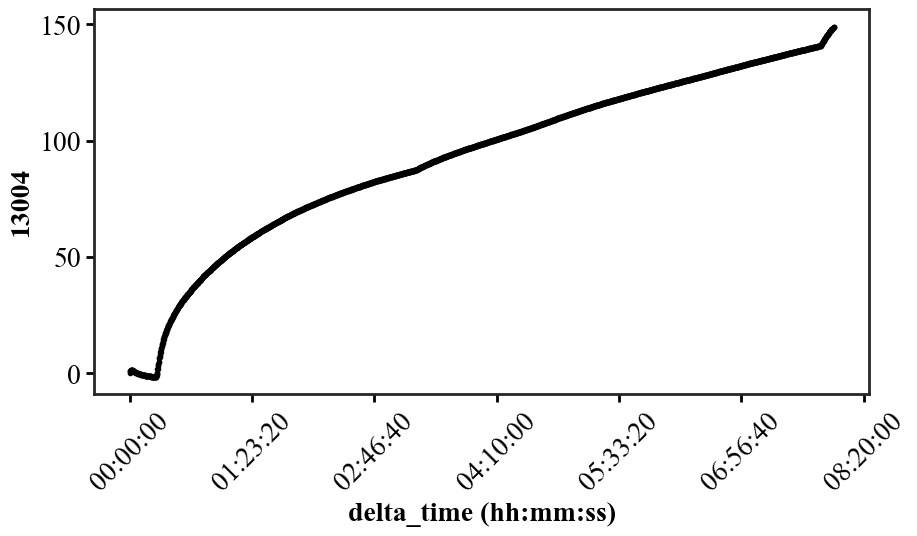

In [5]:
from matplotlib.ticker import FuncFormatter

# 过滤出 Date-Time 在 2022-03-15 09:00:00 起 8 小时内的数据，并以 delta_time 为 x 轴（显示为 hh:mm:ss），13004 为 y 轴绘图
start = pd.Timestamp("2022-03-15 09:00:00")
end = start + pd.Timedelta(hours=8)

mask = (sheet_df["Date-Time"] >= start) & (sheet_df["Date-Time"] <= end)
df_plot = sheet_df.loc[mask].copy()

if df_plot.empty:
    print("指定时间范围内无数据。")
else:
    # 使用 Date-Time - start 作为 x（Timedelta），并把 x 转为秒用于绘图，x 轴标签显示为 hh:mm:ss
    x_td = df_plot["Date-Time"] - start
    x_sec = x_td.dt.total_seconds()
    y = df_plot[13004]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_sec, y, marker=".", linestyle="-")
    ax.set_xlabel("delta_time (hh:mm:ss)")
    ax.set_ylabel("13004")

    def _sec_to_hms(x, pos=None):
        h = int(x // 3600)
        m = int((x % 3600) // 60)
        s = int(x % 60)
        return f"{h:02d}:{m:02d}:{s:02d}"
    ax.xaxis.set_major_formatter(FuncFormatter(_sec_to_hms))

    plt.xticks(rotation=45)
    # plt.tight_layout()
    plt.show()

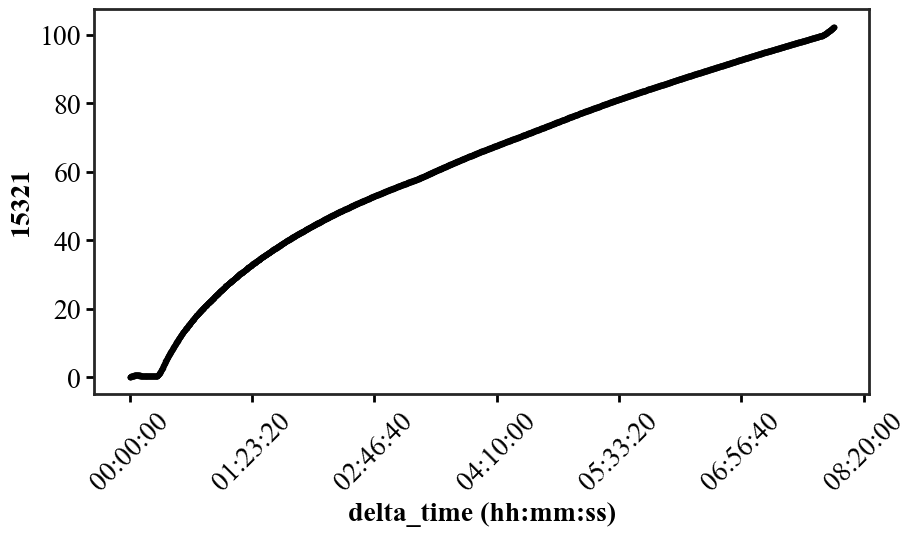

In [6]:
# 以 delta_time 为 x（显示为 hh:mm:ss），15321 为 y 绘图（时间范围已在 df_plot 中筛选）
if df_plot.empty:
    print("指定时间范围内无数据。")
else:
    # 优先复用已计算的 x_sec；若不存在则由 delta_time 解析得到秒数
    x = x_sec if "x_sec" in globals() else pd.to_timedelta(df_plot["delta_time"].astype(str)).dt.total_seconds()
    y_15321 = df_plot[15321]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, y_15321, marker=".", linestyle="-")
    ax.set_xlabel("delta_time (hh:mm:ss)")
    ax.set_ylabel("15321")
    # ax.set_title("delta_time ~ 15321 (2022-03-15 09:00:00 起 8 小时)")

    # 复用已有的格式化函数；若不存在则定义一个
    try:
        fmt = FuncFormatter(_sec_to_hms)
    except NameError:
        def _sec_to_hms(val, pos=None):
            h = int(val // 3600)
            m = int((val % 3600) // 60)
            s = int(val % 60)
            return f"{h:02d}:{m:02d}:{s:02d}"
        fmt = FuncFormatter(_sec_to_hms)

    ax.xaxis.set_major_formatter(fmt)
    plt.xticks(rotation=45)
    # plt.tight_layout()
    plt.show()

## Evo5 pressure fitting (fitting perm and delta p together)

Best-fit k   = 4.965e+01 mD
Best-fit A   = 165.510 psi   (≈ p0 - p1)
Best-fit eta = 3.378e+00 ft^2/s
R^2          = 0.9838


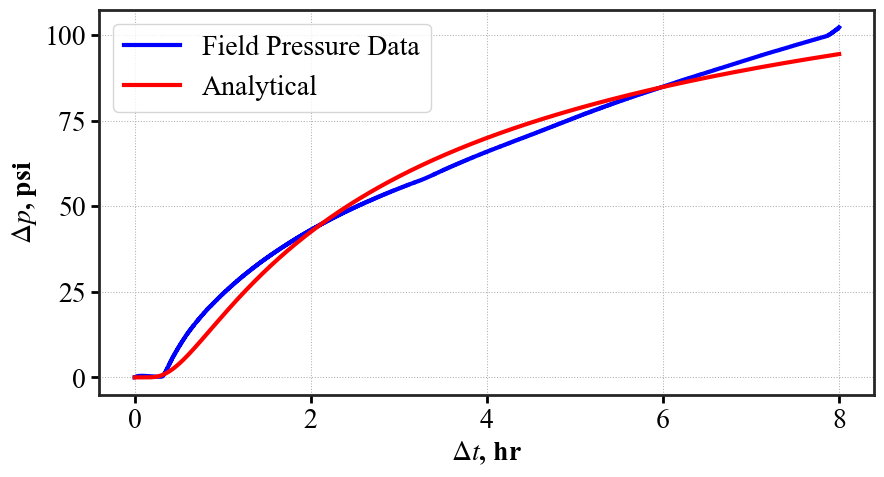

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------- erfc ----------
try:
    from numpy import erfc as _erfc
except Exception:
    import math
    _erfc = np.vectorize(lambda z: 1.0 - math.erf(z))

# ---------- 单位换算与模型 ----------
def diffusivity_ft2_per_s(k_mD, mu_cP, phi, ct_per_psi):
    """k[mD], mu[cP], phi[-], ct[1/psi]  -> η[ft^2/s]"""
    return ((9.869233e-16)/(1e-3)*6894.757*3.2808**2) * k_mD / (mu_cP * phi * ct_per_psi)

def f_kernel(t_sec, k_mD, x_ft, mu_cP, phi, ct_per_psi):
    """f_k(t) = erfc( x / (2*sqrt(η t)) )"""
    t = np.asarray(t_sec, float)
    t = np.clip(t, 1e-9, None)
    eta = diffusivity_ft2_per_s(k_mD, mu_cP, phi, ct_per_psi)
    z = x_ft / (2.0*np.sqrt(eta*t))
    return _erfc(z)

def A_opt_given_k(t_sec, y_psi, k_mD, x_ft, mu_cP, phi, ct_per_psi, nonneg=True):
    """对给定 k 的最优 A（最小二乘解析解），可选非负约束"""
    f = f_kernel(t_sec, k_mD, x_ft, mu_cP, phi, ct_per_psi)
    num = np.nansum(f*y_psi)
    den = np.nansum(f*f)
    if den <= 0:
        return 0.0
    A = num/den
    if nonneg:
        A = max(0.0, A)
    return float(A)

def sse_of_k_log10(logk, t_sec, y_psi, x_ft, mu_cP, phi, ct_per_psi):
    k = 10.0**logk
    A = A_opt_given_k(t_sec, y_psi, k, x_ft, mu_cP, phi, ct_per_psi, nonneg=True)
    yhat = A * f_kernel(t_sec, k, x_ft, mu_cP, phi, ct_per_psi)
    r = y_psi - yhat
    return np.nansum(r*r)

def fit_A_k_dual(t_sec, y_psi, x_ft, mu_cP, phi, ct_per_psi,
                 k_bounds=(1e-6, 10.0), return_curve=True):
    """
    同时拟合 A=(p0-p1) 与 k（mD）。
    方法：在 log10(k) 上黄金分割搜索，A 用解析解。
    """
    t = np.asarray(t_sec, float)
    y = np.asarray(y_psi, float)
    m = np.isfinite(t)&np.isfinite(y)&(t>0)
    t, y = t[m], y[m]
    if t.size < 5:
        raise ValueError("有效数据点不足")

    # 先粗网格确定区间
    lo, hi = np.log10(k_bounds[0]), np.log10(k_bounds[1])
    grid = np.linspace(lo, hi, 200)
    sse_vals = np.array([sse_of_k_log10(g, t, y, x_ft, mu_cP, phi, ct_per_psi) for g in grid])
    j = int(np.argmin(sse_vals))
    a = grid[max(0, j-1)]
    b = grid[min(len(grid)-1, j+1)]
    if j == 0: a, b = lo, grid[3]
    if j == len(grid)-1: a, b = grid[-4], hi

    # 黄金分割
    phi_g = (1 + np.sqrt(5)) / 2
    invphi = 1/phi_g
    c = b - invphi*(b-a)
    d = a + invphi*(b-a)
    fc = sse_of_k_log10(c, t, y, x_ft, mu_cP, phi, ct_per_psi)
    fd = sse_of_k_log10(d, t, y, x_ft, mu_cP, phi, ct_per_psi)
    for _ in range(80):
        if (b - a) < 1e-6:
            break
        if fc < fd:
            b, d, fd = d, c, fc
            c = b - invphi*(b-a)
            fc = sse_of_k_log10(c, t, y, x_ft, mu_cP, phi, ct_per_psi)
        else:
            a, c, fc = c, d, fd
            d = a + invphi*(b-a)
            fd = sse_of_k_log10(d, t, y, x_ft, mu_cP, phi, ct_per_psi)

    logk_best = (a+b)/2.0
    k_best = 10.0**logk_best
    A_best = A_opt_given_k(t, y, k_best, x_ft, mu_cP, phi, ct_per_psi, nonneg=True)
    yhat = A_best * f_kernel(t, k_best, x_ft, mu_cP, phi, ct_per_psi)

    ss_res = np.nansum((y - yhat)**2)
    ss_tot = np.nansum((y - np.nanmean(y))**2)
    R2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    if return_curve:
        return k_best, A_best, R2, (t, yhat)
    else:
        return k_best, A_best, R2

# ===================== 使用示例（与你的数据衔接） =====================
GAUGE_COL = 15321#15321#13004
t_sec = (df_plot["Date-Time"] - df_plot["Date-Time"].iloc[0]).dt.total_seconds().to_numpy()
y_psi = df_plot[GAUGE_COL].to_numpy()

# —— 在这里填入物性与几何（单位务必与注释一致）——

x_ft       = 250       # 计量点到边界/裂缝面的法向距离 [ft]
mu_cP      = 0.185        # 黏度 [cP]
phi        = 0.3       # 孔隙度 [-]
ct_per_psi = 1.94e-5     # 体积压缩系数 [1/psi]



# 拟合（按需要可放宽 k 范围）
k_best_mD, A_best_psi, R2, (t_used, yhat) = fit_A_k_dual(
    t_sec, y_psi, x_ft, mu_cP, phi, ct_per_psi,
    k_bounds=(40, 80.0), return_curve=True
)

eta_best = diffusivity_ft2_per_s(k_best_mD, mu_cP, phi, ct_per_psi)
print(f"Best-fit k   = {k_best_mD:.3e} mD")
print(f"Best-fit A   = {A_best_psi:.3f} psi   (≈ p0 - p1)")
print(f"Best-fit eta = {eta_best:.3e} ft^2/s")
print(f"R^2          = {R2:.4f}")

# 叠加绘图
def _sec_to_hms(x, pos=None):
    h = int(x // 3600); m = int((x % 3600)//60); s = int(x % 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(t_sec, y_psi, color='blue', lw = 3, label='Field Pressure Data')
ax.plot(t_used, yhat, color='red', lw = 3, label='Analytical')
ax.xaxis.set_major_formatter(FuncFormatter(_sec_to_hms))
ax.set_xticks([0, 7200,  14400,  21600, 28800])
ax.set_xticklabels(['0','2','4','6','8'])
ax.yaxis.set_major_locator(MultipleLocator(25))     # 每 2000 ft 一个大刻度


ax.set_xlabel(r'$\Delta t$, hr')
ax.set_ylabel(r'$\Delta p$, psi')
ax.grid(True, which='both', linestyle=':', linewidth=0.75)
ax.legend()

# plt.savefig("pressure_strain_matching_gauge4.png", dpi=600,bbox_inches='tight')

plt.show()
# fig.show()


## Evo7 pressure show


START input: 2022-06-02 08:00:00  --> used: 2022-06-02 08:00:00 (Δt=+0s, idx=192, P0=4188.009)
END   input: 2022-06-02 16:00:00    --> used: 2022-06-02 16:00:00 (Δt=+0s, idx=240, P1=4044.539)
Window length: 8.000 hours

START input: 2022-06-02 08:00:00  --> used: 2022-06-02 08:00:00 (Δt=+0s, idx=192, P0=4644.707)
END   input: 2022-06-02 16:00:00    --> used: 2022-06-02 16:00:00 (Δt=+0s, idx=240, P1=4622.554)
Window length: 8.000 hours

START input: 2022-03-15 09:00:00  --> used: 2022-03-15 09:00:00 (Δt=+0s, idx=3240, P0=7524.264)
END   input: 2022-03-15 17:00:00    --> used: 2022-03-15 17:00:00 (Δt=+0s, idx=6120, P1=7375.379)
Window length: 8.000 hours

START input: 2022-03-15 09:00:00  --> used: 2022-03-15 09:00:00 (Δt=+0s, idx=3240, P0=7494.513)
END   input: 2022-03-15 17:00:00    --> used: 2022-03-15 17:00:00 (Δt=+0s, idx=6120, P1=7392.235)
Window length: 8.000 hours


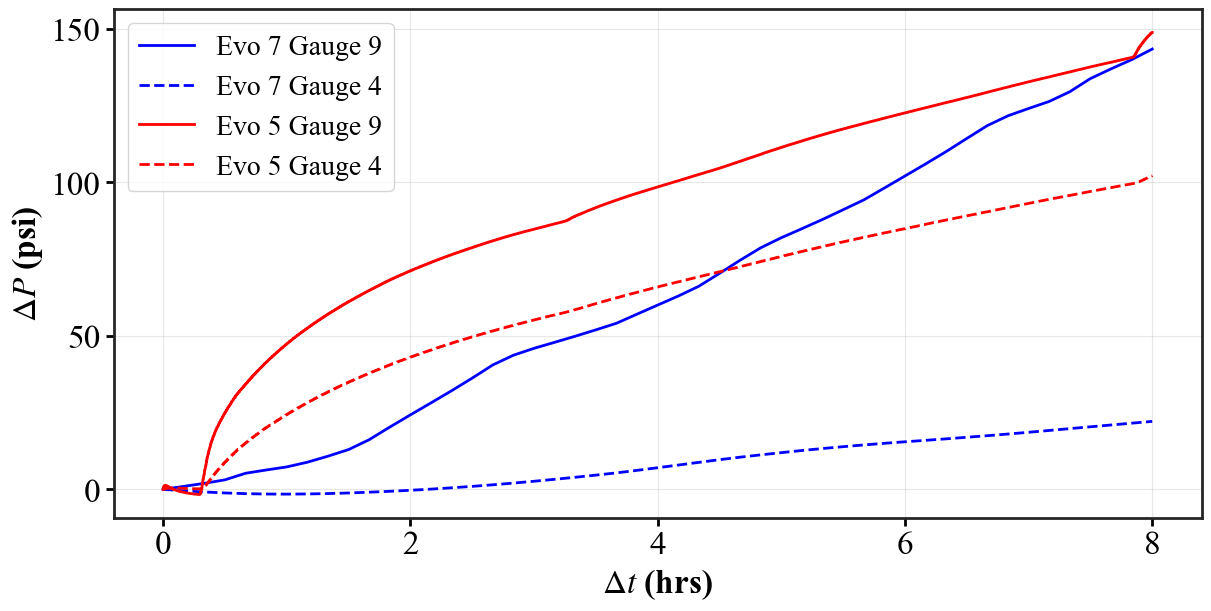

In [144]:
%reload_ext autoreload
%autoreload 2


from plot_style import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) 工具函数
# =========================

def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns={c: str(c).strip().lower().replace(" ", "") for c in df.columns})

def _align_target_tz(target: pd.Timestamp, series_tz):
    """让 target 的时区和 series 一致（避免 tz-aware vs tz-naive 报错）"""
    if series_tz is None:
        # 数据是 naive，target 若带 tz 则去掉 tz
        return target.tz_convert(None) if target.tzinfo is not None else target
    else:
        # 数据带 tz，target 若 naive 则按该 tz localize
        return target.tz_localize(series_tz) if target.tzinfo is None else target.tz_convert(series_tz)

def read_pressure_excel(
    xls_path: str,
    sheet=0,
    time_col="date",
    pressure_col="pressure",
    unit="s",            # 你的 date 是 epoch 秒就用 's'
    tz=None              # 需要的话填 "America/Chicago"，不需要就 None
):
    df = pd.read_excel(xls_path, sheet_name=sheet, engine="openpyxl")
    df = _normalize_columns(df)

    required = {time_col, pressure_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{xls_path} 缺少列: {missing}；当前列为: {list(df.columns)}")

    t_raw = df[time_col]
    p = pd.to_numeric(df[pressure_col], errors="coerce")

    # 时间列：epoch 数值 或 已经是 datetime
    if np.issubdtype(t_raw.dtype, np.number):
        t = pd.to_datetime(t_raw, unit=unit, utc=(tz is not None))
        if tz is not None:
            t = t.dt.tz_convert(tz)
    else:
        t = pd.to_datetime(t_raw, errors="coerce")
        if tz is not None and getattr(t.dt, "tz", None) is None:
            t = t.dt.tz_localize(tz)

    # 只保留到“秒”精度（你要求精确到秒就行）
    t = t.dt.round("s")

    out = pd.DataFrame({"t": t, "p": p}).dropna().sort_values("t").reset_index(drop=True)
    return out


def relative_pressure_in_window(df_tp: pd.DataFrame, start_time, end_time, keep_end=True):
    """
    - start_time / end_time：你输入的时间点（字符串/datetime/Timestamp 都行）
    - 自动找最近采样点作为 start/end
    - dp = p - p(start)
    - hours = (t - t(start)) / 3600
    """
    if df_tp.empty:
        raise ValueError("df_tp 为空")

    series_tz = getattr(df_tp["t"].dt, "tz", None)

    start_in = pd.to_datetime(start_time).round("s")
    end_in   = pd.to_datetime(end_time).round("s")

    start_in = _align_target_tz(start_in, series_tz)
    end_in   = _align_target_tz(end_in, series_tz)

    i0 = int((df_tp["t"] - start_in).abs().idxmin())
    i1 = int((df_tp["t"] - end_in).abs().idxmin())
    if i1 < i0:
        i0, i1 = i1, i0
        start_in, end_in = end_in, start_in  # 让输入也跟着区间方向一致（方便理解）

    t0 = df_tp.loc[i0, "t"]
    p0 = df_tp.loc[i0, "p"]
    t1 = df_tp.loc[i1, "t"]
    p1 = df_tp.loc[i1, "p"]

    dfw = df_tp.iloc[i0:(i1 + 1 if keep_end else i1)].copy()
    dfw["hours_since_start"] = (dfw["t"] - t0).dt.total_seconds() / 3600.0
    dfw["dp"] = dfw["p"] - p0

    meta = {
        "t_start_input": start_in, "t_end_input": end_in,
        "t_start_used": t0, "t_end_used": t1,
        "p_start_used": p0, "p_end_used": p1,
        "dt_start_sec": (t0 - start_in).total_seconds(),
        "dt_end_sec": (t1 - end_in).total_seconds(),
        "i_start": i0, "i_end": i1,
    }
    return dfw, meta



# =========================
# 2) 你只需要改这里：每条曲线一个 config（可无限加）
# =========================
configs = [
    {
        "path": r"C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 7 (flowback)/13004v4.xlsx",
        "sheet": 0,
        "unit": "s",
        "label": "Evo 7 Gauge 9",
        "start_time": "2022-06-02 08:00:00",
        "end_time":   "2022-06-02 16:00:00",
        "style": {"color": "#0000FF", "linestyle": "-",  "linewidth": 2},
    },

    {
        "path": r"C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 7 (flowback)/15321v6.xlsx",
        "sheet": 0,
        "unit": "s",
        "label": "Evo 7 Gauge 4",
        "start_time": "2022-06-02 08:00:00",
        "end_time":   "2022-06-02 16:00:00",
        "style": {"color": "#0000FF", "linestyle": "--",  "linewidth": 2},
    },

    {
        "path": r"C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/20220707/Evo 5 (POP)/13004.xlsx",
        "sheet": 0,
        "unit": "s",
        "label": "Evo 5 Gauge 9",
        "start_time": "2022-03-15 09:00:00",
        "end_time":   "2022-03-15 17:00:00",
        "style": {"color": "red", "linestyle": "-",  "linewidth": 2},
    },

    {
        "path": r"C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/20220707/Evo 5 (POP)/15321.xlsx",
        "sheet": 0,
        "unit": "s",
        "label": "Evo 5 Gauge 4",
        "start_time": "2022-03-15 09:00:00",
        "end_time":   "2022-03-15 17:00:00",
        "style": {"color": "red", "linestyle": "--",  "linewidth": 2},
    },

]

# =========================
# 3) 批量计算 + 叠图
# =========================
fig, ax = make_standard_figure(figsize=(12, 6), )#color_cycle = ("red","red","blue","blue")

for cfg in configs:
    df_tp = read_pressure_excel(
        cfg["path"],
        sheet=cfg.get("sheet", 0),
        unit=cfg.get("unit", "s"),
        tz=cfg.get("tz", None),   # 需要时区就填 "America/Chicago"
    )

    df_rel, meta = relative_pressure_in_window(df_tp, cfg["start_time"], cfg["end_time"])

    # ===== 打印匹配到的时间点信息 =====
    print("\n" + "="*80)
    # print(f'File: {cfg["path"]}')
    # print(f'Label: {cfg.get("label","")}')
    print(f'START input: {meta["t_start_input"]}  --> used: {meta["t_start_used"]} '
          f'(Δt={meta["dt_start_sec"]:+.0f}s, idx={meta["i_start"]}, P0={meta["p_start_used"]:.3f})')
    print(f'END   input: {meta["t_end_input"]}    --> used: {meta["t_end_used"]} '
          f'(Δt={meta["dt_end_sec"]:+.0f}s, idx={meta["i_end"]}, P1={meta["p_end_used"]:.3f})')
    print(f'Window length: {(meta["t_end_used"] - meta["t_start_used"]).total_seconds()/3600.0:.3f} hours')
    print("="*80)

    label = (
        f'{cfg.get("label","")}'
        # f'start_used={pd.to_datetime(meta["t_start_used"]).strftime("%Y-%m-%d %H:%M:%S")}, '
        # f'end_used={pd.to_datetime(meta["t_end_used"]).strftime("%Y-%m-%d %H:%M:%S")}'
    )

    style = cfg.get("style", {})  # 没写就默认 Matplotlib 循环色
    line, = ax.plot(df_rel["hours_since_start"],
                    -1*df_rel["dp"],
                    label=cfg.get("label",""),
                      **style)
    # ax.plot(df_rel["hours_since_start"], df_rel["dp"]*-1, lw=1.8, label=label)

ax.set_xlabel(r"$\Delta t$ (hrs)")
ax.set_ylabel(r"$\Delta P$ (psi)")
from matplotlib.ticker import MultipleLocator
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.yaxis.set_major_locator(MultipleLocator(50))
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
# plt.tight_layout()
plt.show()


## Evo7 pressure fitting (fitting perm and delta p together)

In [142]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------- erfc ----------
try:
    from numpy import erfc as _erfc
except Exception:
    import math
    _erfc = np.vectorize(lambda z: 1.0 - math.erf(z))

# ---------- 单位换算与模型 ----------
def diffusivity_ft2_per_s(k_mD, mu_cP, phi, ct_per_psi):
    """k[mD], mu[cP], phi[-], ct[1/psi]  -> η[ft^2/s]"""
    return ((9.869233e-16)/(1e-3)*6894.757*3.2808**2) * k_mD / (mu_cP * phi * ct_per_psi)

def f_kernel(t_sec, k_mD, x_ft, mu_cP, phi, ct_per_psi):
    """f_k(t) = erfc( x / (2*sqrt(η t)) )"""
    t = np.asarray(t_sec, float)
    t = np.clip(t, 1e-9, None)
    eta = diffusivity_ft2_per_s(k_mD, mu_cP, phi, ct_per_psi)
    z = x_ft / (2.0*np.sqrt(eta*t))
    return _erfc(z)

def A_opt_given_k(t_sec, y_psi, k_mD, x_ft, mu_cP, phi, ct_per_psi, nonneg=True):
    """对给定 k 的最优 A（最小二乘解析解），可选非负约束"""
    f = f_kernel(t_sec, k_mD, x_ft, mu_cP, phi, ct_per_psi)
    num = np.nansum(f*y_psi)
    den = np.nansum(f*f)
    if den <= 0:
        return 0.0
    A = num/den
    if nonneg:
        A = max(0.0, A)
    return float(A)

def sse_of_k_log10(logk, t_sec, y_psi, x_ft, mu_cP, phi, ct_per_psi):
    k = 10.0**logk
    A = A_opt_given_k(t_sec, y_psi, k, x_ft, mu_cP, phi, ct_per_psi, nonneg=True)
    yhat = A * f_kernel(t_sec, k, x_ft, mu_cP, phi, ct_per_psi)
    r = y_psi - yhat
    return np.nansum(r*r)

def fit_A_k_dual(t_sec, y_psi, x_ft, mu_cP, phi, ct_per_psi,
                 k_bounds=(1e-6, 10.0), return_curve=True):
    """
    同时拟合 A=(p0-p1) 与 k（mD）。
    方法：在 log10(k) 上黄金分割搜索，A 用解析解。
    """
    t = np.asarray(t_sec, float)
    y = np.asarray(y_psi, float)
    m = np.isfinite(t)&np.isfinite(y)&(t>0)
    t, y = t[m], y[m]
    if t.size < 5:
        raise ValueError("有效数据点不足")

    # 先粗网格确定区间
    lo, hi = np.log10(k_bounds[0]), np.log10(k_bounds[1])
    grid = np.linspace(lo, hi, 200)
    sse_vals = np.array([sse_of_k_log10(g, t, y, x_ft, mu_cP, phi, ct_per_psi) for g in grid])
    j = int(np.argmin(sse_vals))
    a = grid[max(0, j-1)]
    b = grid[min(len(grid)-1, j+1)]
    if j == 0: a, b = lo, grid[3]
    if j == len(grid)-1: a, b = grid[-4], hi

    # 黄金分割
    phi_g = (1 + np.sqrt(5)) / 2
    invphi = 1/phi_g
    c = b - invphi*(b-a)
    d = a + invphi*(b-a)
    fc = sse_of_k_log10(c, t, y, x_ft, mu_cP, phi, ct_per_psi)
    fd = sse_of_k_log10(d, t, y, x_ft, mu_cP, phi, ct_per_psi)
    for _ in range(80):
        if (b - a) < 1e-6:
            break
        if fc < fd:
            b, d, fd = d, c, fc
            c = b - invphi*(b-a)
            fc = sse_of_k_log10(c, t, y, x_ft, mu_cP, phi, ct_per_psi)
        else:
            a, c, fc = c, d, fd
            d = a + invphi*(b-a)
            fd = sse_of_k_log10(d, t, y, x_ft, mu_cP, phi, ct_per_psi)

    logk_best = (a+b)/2.0
    k_best = 10.0**logk_best
    A_best = A_opt_given_k(t, y, k_best, x_ft, mu_cP, phi, ct_per_psi, nonneg=True)
    yhat = A_best * f_kernel(t, k_best, x_ft, mu_cP, phi, ct_per_psi)

    ss_res = np.nansum((y - yhat)**2)
    ss_tot = np.nansum((y - np.nanmean(y))**2)
    R2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    if return_curve:
        return k_best, A_best, R2, (t, yhat)
    else:
        return k_best, A_best, R2

def extract_vars_for_fit(df_rel, use_negative_dp=True):
    """
    df_rel: 你的 relative_pressure_in_window 输出
    use_negative_dp=True 表示 y 用 -dp（与你现在画图一致：-1*dp）
    返回：
      t_hr_plot: 画图用小时
      t_sec_fit: 拟合用秒
      y_psi_fit: 拟合用 y（psi）
    """
    t_hr_plot = df_rel["hours_since_start"].to_numpy(dtype=float)
    dp = df_rel["dp"].to_numpy(dtype=float)

    y_psi_fit = (-dp) if use_negative_dp else (dp)
    t_sec_fit = t_hr_plot * 3600.0
    return t_hr_plot, t_sec_fit, y_psi_fit

[Evo 7 Gauge 4] k=8.5685 mD, A=131.128 psi, R2=0.9891


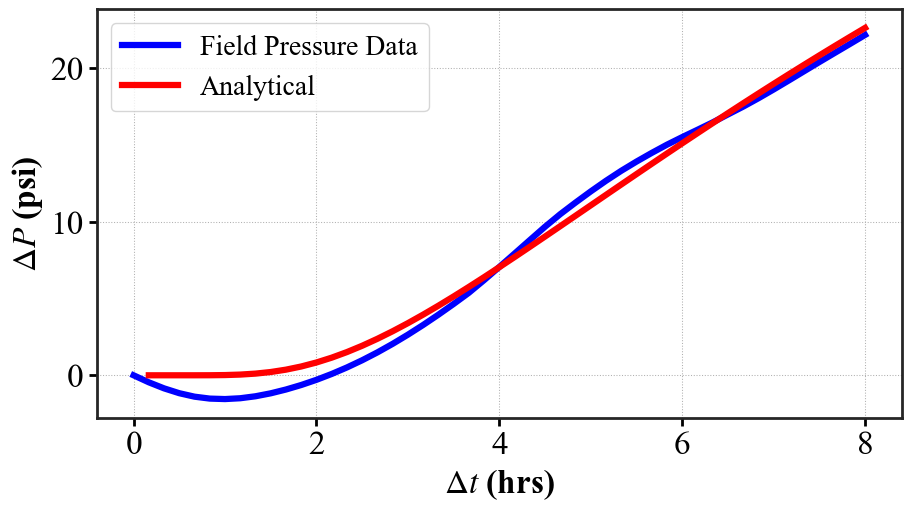

In [145]:
# =========================
# 4) 选择要拟合哪一条曲线（改这个索引就行）
# =========================
fit_idx = 1  # 0 -> configs[0] (Gauge 9), 1 -> configs[1] (Gauge 4)

cfg = configs[fit_idx]

# 读数据 + 截窗口
df_tp = read_pressure_excel(
    cfg["path"],
    sheet=cfg.get("sheet", 0),
    unit=cfg.get("unit", "s"),
    tz=cfg.get("tz", None),
)
df_rel, meta = relative_pressure_in_window(df_tp, cfg["start_time"], cfg["end_time"])

# 从“画图用变量”提出来，转成“拟合用变量”
t_hr  = df_rel["hours_since_start"].to_numpy(dtype=float)           # 画图用（小时）
y_psi = (-1.0 * df_rel["dp"]).to_numpy(dtype=float)                 # 你现在画的是 -dp
t_sec = t_hr * 3600.0                                               # 拟合用（秒）

# ===== 物性与几何（你的）=====
x_ft       = 250
mu_cP      = 0.185
phi        = 0.3
ct_per_psi = 1.94e-5

# 拟合（只拟合这一条）
k_best_mD, A_best_psi, R2, (t_used_sec, yhat) = fit_A_k_dual(
    t_sec, y_psi,
    x_ft, mu_cP, phi, ct_per_psi,
    k_bounds=(1, 40.0),
    return_curve=True
)

print(f'[{cfg["label"]}] k={k_best_mD:.4f} mD, A={A_best_psi:.3f} psi, R2={R2:.4f}')

# 画：一条现场曲线 + 一条拟合曲线
fig, ax = make_standard_figure(figsize=(9, 5))
ax.plot(t_hr, y_psi, color='blue', lw = 4.5, label='Field Pressure Data')
ax.plot(t_used_sec/3600.0, yhat, color='red', lw = 4.5, label='Analytical')

from matplotlib.ticker import MultipleLocator
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.yaxis.set_major_locator(MultipleLocator(10))     # 每 25 psi 一个大刻度
# ax.set_ylim(-10, 160)


ax.set_xlabel(r"$\Delta t$ (hrs)")
ax.set_ylabel(r"$\Delta P$ (psi)")
ax.grid(True,which='both', linestyle=':', linewidth=0.75)
ax.legend(loc="best")
plt.show()




# ax.xaxis.set_major_formatter(FuncFormatter(_sec_to_hms))
# ax.set_xticks([0, 7200,  14400,  21600, 28800])
# ax.set_xticklabels(['0','2','4','6','8'])
# ax.yaxis.set_major_locator(MultipleLocator(25))     # 每 2000 ft 一个大刻度


# ax.set_xlabel(r'$\Delta t$, hr')
# ax.set_ylabel(r'$\Delta p$, psi')
# ax.grid(True, which='both', linestyle=':', linewidth=0.75)







In [ ]:


# —— 在这里填入物性与几何（单位务必与注释一致）——

x_ft       = 250       # 计量点到边界/裂缝面的法向距离 [ft]
mu_cP      = 0.185        # 黏度 [cP]
phi        = 0.3       # 孔隙度 [-]
ct_per_psi = 1.94e-5     # 体积压缩系数 [1/psi]



# 拟合（按需要可放宽 k 范围）
k_best_mD, A_best_psi, R2, (t_used, yhat) = fit_A_k_dual(
    t_sec, y_psi, x_ft, mu_cP, phi, ct_per_psi,
    k_bounds=(40, 80.0), return_curve=True
)

eta_best = diffusivity_ft2_per_s(k_best_mD, mu_cP, phi, ct_per_psi)
print(f"Best-fit k   = {k_best_mD:.3e} mD")
print(f"Best-fit A   = {A_best_psi:.3f} psi   (≈ p0 - p1)")
print(f"Best-fit eta = {eta_best:.3e} ft^2/s")
print(f"R^2          = {R2:.4f}")

# 叠加绘图
def _sec_to_hms(x, pos=None):
    h = int(x // 3600); m = int((x % 3600)//60); s = int(x % 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(t_sec, y_psi, color='blue', lw = 3, label='Field Pressure Data')
ax.plot(t_used, yhat, color='red', lw = 3, label='Analytical')
ax.xaxis.set_major_formatter(FuncFormatter(_sec_to_hms))
ax.set_xticks([0, 7200,  14400,  21600, 28800])
ax.set_xticklabels(['0','2','4','6','8'])
ax.yaxis.set_major_locator(MultipleLocator(25))     # 每 2000 ft 一个大刻度


ax.set_xlabel(r'$\Delta t$, hr')
ax.set_ylabel(r'$\Delta p$, psi')
ax.grid(True, which='both', linestyle=':', linewidth=0.75)
ax.legend()

plt.savefig("pressure_strain_matching_gauge4.png", dpi=600,bbox_inches='tight')

plt.show()
# fig.show()


# strain change data

## Evo5 strain change show

In [9]:
# import packages
import h5py # read h5

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from matplotlib import rc
from cycler import cycler

import numpy as np
import pandas as pd

from merge_h5_files import merge_preserve_time
import os
import glob

In [10]:
# Read h5 files
f1 = h5py.File('C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/20220707/Evo 5 (POP)/Zgabay A14H - pop - strain change.h5','r')
# f1 = h5py.File('C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 7 (flowback)/Zgabay A14H - flowback - strain change.h5','r')
print(list(f1.keys()))
# 继续进入下一层
data_group = f1['data']
print(data_group)
# print(list(data_group.keys()))
# 继续进入下一层
# data_group2 = data_group['Raw[0]']
# print(list(data_group2.keys()))
# 继续进入下一层
# RawData = data_group2['RawData']
# print(RawData)
# RawDataTime = data_group2['RawDataTime']
# print(RawDataTime)

['data', 'depth', 'stamps', 'stamps_unix']
<HDF5 dataset "data": shape (7008, 57218), type "<f4">


In [11]:
from slippage_clbrt_shift import shift_depth_piecewise, invert_shift_depth_piecewise

gauges = np.array([13004, 15321, 13753.1])
gauge_to_fiber = invert_shift_depth_piecewise(gauges, z0=12000.0, z1=16000.0, s0=145.0, s1=160.0)
print("测点深度 gauges: ", gauges)
print("对应纤维深度 gauge_to_fiber: ", gauge_to_fiber)

测点深度 gauges:  [13004.  15321.  13753.1]
对应纤维深度 gauge_to_fiber:  [12855.79078456 15164.13449564 13602.09215442]


In [12]:
from tomlkit import date


dstrain = (f1['data'])  #（time, depth）
depth = (f1['depth'])
date_str = (f1['stamps'])
date_utc = (f1['stamps_unix'])


depth = np.asarray(depth)
dstrain = np.asarray(dstrain)
date_str = np.asarray(date_str)
date_utc = np.asarray(date_utc)

In [13]:
def nearest_col_indices(depth_1d, targets):
    """
    targets 可以是标量或数组。返回与每个 target 最近的列索引。
    """
    t = np.atleast_1d(targets).astype(float)
    # 计算 |depth - target| 并在列轴上取最小
    idx = np.argmin(np.abs(depth_1d[None, :] - t[:, None]), axis=1)
    return idx

#没有做gauge 的depth calibration 的时候用
# gauge_to_fiber = np.array([12712, 12873, 13100, 13352, 13746,13850,14268,14537,
#                            14599, 14842, 15150, 15453, 15691,15726,15747,16056])



targets = gauge_to_fiber
idx = nearest_col_indices(depth, targets)
depth_near = depth[idx]
err = targets - depth_near

print("targets:    ", targets)
print("idx:        ", idx)
print("depth_near: ", depth_near)
print("error(ft):  ", err)


targets:     [12855.79078456 15164.13449564 13602.09215442]
idx:         [38986 45986 41249]
depth_near:  [12855.825 15164.092 13602.053]
error(ft):   [-0.03441075  0.04269877  0.03942005]


In [24]:
#选某个深度（列），可在后面的idx[1]进行加或者减
cols = dstrain[:, idx[1]+1]   #0-6   [1]+1   [2]+1    # shape = (N_time, len(targets)) 
cols = dstrain[:, 38944] #38944  #45900
#随着生产的进行，裂缝闭合，应变变小（绝对值变大），比如从-1变成-5
cols = -1 * cols
# cols = dstrain[:, idx [1]-86]                 # shape = (N_time, len(targets)) 
# cols*=-1

length = len(cols)
print(f"读取 {length} 条记录")
print("cols", cols)

读取 7008 条记录
cols [0.        0.        0.        ... 6.4721313 6.4721313 6.4721313]


In [25]:
#  你的字符串列是 bytes，需要先解码成 str 再解析为 datetime（naive）
ds = pd.to_datetime(pd.Series(date_str.astype(str)), format='%m/%d/%Y %H:%M:%S.%f')
# print(type(ds))
# print(ds)

#取部分数据进行绘图

# ---- 3) 设定你要显示的时间段（同一时区！）----
# start = pd.Timestamp("2022-06-02 08:00:00")
# end   = pd.Timestamp("2022-06-02 16:00:00")
start = pd.Timestamp("2022-03-15 09:00:00")
end   = pd.Timestamp("2022-03-15 17:00:00")
# end   = pd.Timestamp("2022-03-21 18:00:00")

mask = (ds >= start) & (ds <= end)
# mask = np.ones(len(ds), dtype=bool)

t_sel    = ds[mask]
print(mask)
# print(t_sel)


0       False
1       False
2       False
3       False
4       False
        ...  
7003    False
7004    False
7005    False
7006    False
7007    False
Length: 7008, dtype: bool


In [26]:
# 完整输入mask

# 打印 mask 在 ds 中为 True 的位置索引（按位置编号）
import numpy as np
idx_true = np.flatnonzero(mask.to_numpy())
print(f"mask True indices count = {idx_true.size}")
if idx_true.size <= 200:
    print("indices:", idx_true.tolist())
else:
    print("indices (first 50):", idx_true[:50].tolist())
    print("indices (last 50):", idx_true[-50:].tolist())

# 如需查看对应的时间戳：
if idx_true.size <= 50:
    print(ds.iloc[idx_true].to_string(index=True))

# === 找出 mask 从 False->True 与 True->False 的边界（支持多段） ===
m = mask.to_numpy()
n = m.size
if n == 0:
    print("mask is empty")
else:
    d = np.diff(m.astype(np.int8))
    seg_starts = np.flatnonzero(d == 1) + 1  # False->True 的下一个位置
    seg_ends   = np.flatnonzero(d == -1)     # True->False 的当前位置-1
    if m[0]:
        seg_starts = np.r_[0, seg_starts]
    if m[-1]:
        seg_ends = np.r_[seg_ends, n-1]
    segments = list(zip(seg_starts, seg_ends))
    print(f"True segments (inclusive index ranges, count={len(segments)}):")
    for (s,e) in (segments[:5] if len(segments) > 0 else []):
        print(f"  [{s}, {e}]  len={e - s + 1}    {ds.iloc[s]} -> {ds.iloc[e]}")
    if len(segments) > 5:
        print("  ...")
    if segments:
        s0, e0 = segments[0]
        sL, eL = segments[-1]
        print(f"First True block: start={s0}, end={e0}  ({ds.iloc[s0]} -> {ds.iloc[e0]})")
        print(f"Last True block:  start={sL}, end={eL}  ({ds.iloc[sL]} -> {ds.iloc[eL]})")
    
    # 可选：若 ds 是升序的，给出 searchsorted 估计边界
    try:
        i_left = int(ds.searchsorted(start, side='left'))
        i_right = int(ds.searchsorted(end, side='right') - 1)
        print(f"searchsorted bounds (assuming ds sorted): left={i_left}, right={i_right}")
    except Exception:
        pass


mask True indices count = 341
indices (first 50): [514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538, 539, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563]
indices (last 50): [805, 806, 807, 808, 809, 810, 811, 812, 813, 814, 815, 816, 817, 818, 819, 820, 821, 822, 823, 824, 825, 826, 827, 828, 829, 830, 831, 832, 833, 834, 835, 836, 837, 838, 839, 840, 841, 842, 843, 844, 845, 846, 847, 848, 849, 850, 851, 852, 853, 854]
True segments (inclusive index ranges, count=1):
  [514, 854]  len=341    2022-03-15 09:00:21.241823 -> 2022-03-15 16:59:35.315370
First True block: start=514, end=854  (2022-03-15 09:00:21.241823 -> 2022-03-15 16:59:35.315370)
Last True block:  start=514, end=854  (2022-03-15 09:00:21.241823 -> 2022-03-15 16:59:35.315370)
searchsorted bounds (assuming ds sorted): left=514, right=854


In [27]:
strian_sel    = cols[mask]
strian_sel = strian_sel - strian_sel[0]  # 以起始点为零点
# print(type(strian_sel))
# print(strian_sel)
print(len(strian_sel))

341


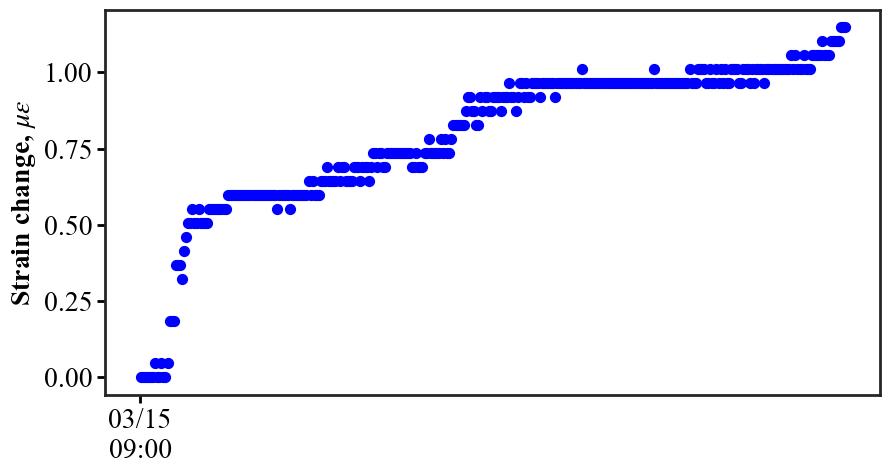

In [28]:
fig, ax = plt.subplots(figsize=(10,5))

#scatter plot
ax.scatter(t_sel, strian_sel, color='blue', s=50, label='Field Pressure Data')

ax.xaxis_date()
date_format = mdates.DateFormatter('%m/%d\n%H:%M')
ax.xaxis.set_major_formatter(date_format)

# start = datetime.datetime(2022, 6, 2, 8, 0)
# end   = datetime.datetime(2022, 6, 2, 16, 0)
# start = datetime.datetime(2022, 3, 15, 0, 0)
# end   = datetime.datetime(2022, 3, 21, 20, 0)
start = datetime.datetime(2022, 3, 15, 9, 0)
end   = datetime.datetime(2022, 3, 15, 17, 0)


ticks = pd.date_range(start, end, freq='1d')  # 每 4 小时一个
ax.set_xticks(ticks)
ax.set_ylabel(r"Strain change, $\mu\varepsilon$")

# 设置主刻度间隔为 1 小时
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))

# 给外侧轴留空间，避免被裁切
# fig.subplots_adjust(right=0.82)
# plt.savefig('frac_curves_S6.png', dpi=600, bbox_inches='tight')
plt.show()



## Evo5 strain change fitting

[strain-fit] k  = 1.625e+02 mD
[strain-fit] η  = 1.105e+01 ft^2/s
[strain-fit] A  = 1.34 με   (幅值 = α/E*(1-2ν)/(1-ν)*(p_i-p_1))
[strain-fit] R² = 0.9264


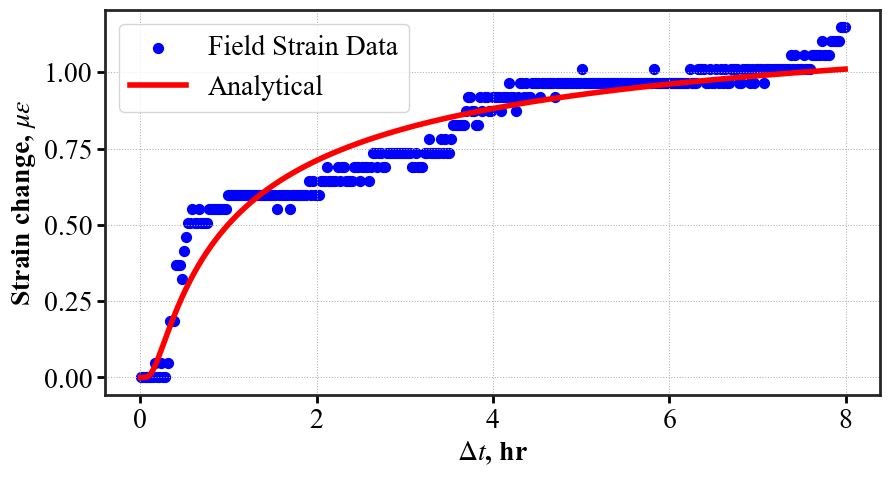

In [32]:
# ================== 只拟合 A 与 k 的简洁版（无 B、无 tau） ==================
from turtle import color
import numpy as np

# erfc 内核
try:
    from numpy import erfc as _erfc
except Exception:
    import math
    _erfc = np.vectorize(lambda z: 1.0 - math.erf(z))


def diffusivity_ft2_per_s(k_mD, mu_cP, phi, ct_per_psi):
    """k[mD], mu[cP], phi[-], ct[1/psi]  -> η[ft^2/s]"""
    k_m2 = k_mD * 9.869233e-16      # mD -> m^2
    mu_Pa_s = mu_cP * 1e-3          # cP -> Pa*s
    ct_per_Pa = ct_per_psi / 6894.757  # 1/psi -> 1/Pa
    eta_m2_s = k_m2 / (mu_Pa_s * phi * ct_per_Pa)
    eta_ft2_s = eta_m2_s * (3.280839895**2)
    return eta_ft2_s


# f_k(t) = erfc( dis / (2*sqrt(η*t)) )
def f_kernel(t_sec, k_mD, dis_ft, mu_cP, phi, ct_per_psi):
    t = np.asarray(t_sec, float)
    t = np.clip(t, 1e-9, None)  # 避免 t=0
    eta = diffusivity_ft2_per_s(k_mD, mu_cP, phi, ct_per_psi)
    z = dis_ft / (2.0 * np.sqrt(eta * t))
    return _erfc(z)


# 给定 k 的最优 A（解析最小二乘）
def A_opt_given_k(t_sec, y_vals, k_mD, dis_ft, mu_cP, phi, ct_per_psi, nonneg=True):
    f = f_kernel(t_sec, k_mD, dis_ft, mu_cP, phi, ct_per_psi)
    num = np.nansum(f * y_vals)
    den = np.nansum(f * f)
    if den <= 0:
        return 0.0
    A = num / den
    if nonneg:
        A = max(0.0, A)
    return float(A)

# SSE(log10 k)
def sse_of_logk(logk, t_sec, y_vals, dis_ft, mu_cP, phi, ct_per_psi):
    k = 10.0 ** logk
    A = A_opt_given_k(t_sec, y_vals, k, dis_ft, mu_cP, phi, ct_per_psi, nonneg=True)
    yhat = A * f_kernel(t_sec, k, dis_ft, mu_cP, phi, ct_per_psi)
    r = y_vals - yhat
    return float(np.nansum(r * r))

# 简单的一维黄金分割（log10 k 空间）
def golden_search_1d(fun, a, b, tol=1e-6, iters=80):
    phi = (1 + np.sqrt(5)) / 2
    invphi = 1 / phi
    c = b - invphi * (b - a)
    d = a + invphi * (b - a)
    fc, fd = fun(c), fun(d)
    for _ in range(iters):
        if (b - a) < tol:
            break
        if fc < fd:
            b, d, fd = d, c, fc
            c = b - invphi * (b - a)
            fc = fun(c)
        else:
            a, c, fc = c, d, fd
            d = a + invphi * (b - a)
            fd = fun(d)
    return (a + b) / 2.0

# 主拟合函数：只拟合 A（με）和 k（mD）
def fit_A_k_strain(t_sec, y_ueps, dis_ft, mu_cP, phi, ct_per_psi,
                   k_bounds=(1e-6, 1e3), return_curve=True):
    t = np.asarray(t_sec, float)
    y = np.asarray(y_ueps, float)
    # m = np.isfinite(t) & np.isfinite(y) & (t > 0)
    m = np.isfinite(t) & np.isfinite(y) & (t >= 0)
    t, y = t[m], y[m]

    t = np.clip(t, 1e-9, None)
    
    if t.size < 5:
        raise ValueError("有效点太少，无法拟合。")

    # 粗网格锁区间
    lo, hi = np.log10(k_bounds[0]), np.log10(k_bounds[1])
    grid = np.linspace(lo, hi, 200)
    sse_vals = np.array([sse_of_logk(g, t, y, dis_ft, mu_cP, phi, ct_per_psi) for g in grid])
    j = int(np.argmin(sse_vals))
    a = grid[max(0, j-1)]
    b = grid[min(len(grid)-1, j+1)]
    if j == 0: a, b = lo, grid[3]
    if j == len(grid)-1: a, b = grid[-4], hi

    # 黄金分割精化
    logk_best = golden_search_1d(
        lambda lk: sse_of_logk(lk, t, y, dis_ft, mu_cP, phi, ct_per_psi), a, b,
        tol=1e-6, iters=80
    )
    k_best_mD = 10.0 ** logk_best
    A_best = A_opt_given_k(t, y, k_best_mD, dis_ft, mu_cP, phi, ct_per_psi, nonneg=True)
    yhat = A_best * f_kernel(t, k_best_mD, dis_ft, mu_cP, phi, ct_per_psi)

    # R^2
    ss_res = np.nansum((y - yhat)**2)
    ss_tot = np.nansum((y - np.nanmean(y))**2)
    R2 = 1.0 - ss_res/ss_tot if ss_tot > 0 else np.nan

    if return_curve:
        return k_best_mD, A_best, R2, (t, yhat)
    else:
        return k_best_mD, A_best, R2

# ================== 准备拟合所需 t(秒) 和 y(με) ==================
# 以可见窗口起点为 t=0
t0 = t_sel.iloc[0]
t_sec = (t_sel - t0).dt.total_seconds().to_numpy()
y_ueps = strian_sel.astype(float)  # 单位：με（microstrain）

# ================== 这里填写物性与几何（单位务必正确） ==================
dis_ft       = 250        # 纤维点到压力阶跃/裂缝面的法向距离 [ft]
mu_cP        = 0.185       # 黏度 [cP]
phi          = 0.30        # 孔隙度 [-]
ct_per_psi   = 1.94e-5     # 总压缩系数 [1/psi]

# ================== 执行拟合并叠加到现有散点图 ==================
k_best, A_best, R2, (t_used, yhat) = fit_A_k_strain(
    t_sec, y_ueps, dis_ft, mu_cP, phi, ct_per_psi,
    k_bounds=(1e-6, 1e3), return_curve=True
)
eta_best = diffusivity_ft2_per_s(k_best, mu_cP, phi, ct_per_psi)

print(f"[strain-fit] k  = {k_best:.3e} mD")
print(f"[strain-fit] η  = {eta_best:.3e} ft^2/s")
print(f"[strain-fit] A  = {A_best:.2f} με   (幅值 = α/E*(1-2ν)/(1-ν)*(p_i-p_1))")
print(f"[strain-fit] R² = {R2:.4f}")

# 叠加绘图
def _sec_to_hms(x, pos=None):
    h = int(x // 3600); m = int((x % 3600)//60); s = int(x % 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

fig2, ax2 = plt.subplots(figsize=(10,5))
ax2.scatter(t_sel, y_ueps, s=50, label='Field Strain Data', color='blue')

t_used_dt = pd.to_datetime(t_used, unit='s', origin=t0)
ax2.plot(t_used_dt, yhat, lw=4, color='red',
         label='Analytical')
        #  label=f"fit: k={k_best:.2e} mD, A={A_best:.1f} με, R²={R2:.3f}")

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d\n%H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=4))
# ax2.xaxis.set_major_formatter(FuncFormatter(_sec_to_hms))
# ax2.set_xticks([0, 7200,  14400,  21600, 28800])
# ax2.set_xticklabels(['0','2','4','6','8'])
# ax2.set_xlabel(r'$\Delta t$, hr')

# start = datetime.datetime(2022, 6, 2, 8, 0)
# end   = datetime.datetime(2022, 6, 2, 16, 0)

start = datetime.datetime(2022, 3, 15, 9, 0)
end   = datetime.datetime(2022, 3, 15, 17, 0)

ticks = pd.date_range(start, end, freq='2h')  # 每 4 小时一个
ax2.set_xticks(ticks)
ax2.set_xticklabels(['0','2','4','6','8'])
ax2.set_xlabel(r'$\Delta t$, hr')

ax2.set_ylabel(r"Strain change, $\mu\varepsilon$")
ax2.legend()
ax2.grid(True, which='both', linestyle=':', linewidth=0.75)
# plt.tight_layout()
plt.show()


In [29]:
print("NaT:", ds.isna().sum())
print("sorted:", ds.is_monotonic_increasing)


NaT: 0
sorted: True


In [30]:
print("selected points:", mask.sum())
print(t_sel.iloc[0], t_sel.iloc[-1])


selected points: 341
2022-03-15 09:00:21.241823 2022-03-15 16:59:35.315370


In [31]:
print(t_sec[:5], y_ueps[:5], y_ueps.min(), y_ueps.max())


[  0.        84.415226 169.361761 254.245788 338.629798] [0. 0. 0. 0. 0.] -0.045901596546173096 0.8262295126914978


## Evo7 strain change show

In [2]:
# import packages
import h5py # read h5

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from matplotlib import rc
from cycler import cycler

import numpy as np
import pandas as pd

from merge_h5_files import merge_preserve_time
import os
import glob

In [4]:
# Read h5 files
# f1 = h5py.File('C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/20220707/Evo 5 (POP)/Zgabay A14H - pop - strain change.h5','r')
# f1 = h5py.File('C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 7 (flowback)/Zgabay A14H - flowback - strain change.h5','r')
f1 = h5py.File('C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 7 (flowback)/corrected_within_1h_(with_data_wash).h5','r')

print(list(f1.keys()))
# 继续进入下一层
# data_group = f1['data']
data_group = f1['strain_corrected']

print(data_group)
# print(list(data_group.keys()))
# 继续进入下一层
# data_group2 = data_group['Raw[0]']
# print(list(data_group2.keys()))
# 继续进入下一层
# RawData = data_group2['RawData']
# print(RawData)
# RawDataTime = data_group2['RawDataTime']
# print(RawDataTime)

['depth', 'first_slip_neg_t', 'first_slip_pos_t', 'first_spike_neg_t', 'first_spike_pos_t', 'n_slip_neg', 'n_slip_pos', 'n_spike_neg', 'n_spike_pos', 'rate_corrected', 'slippage_flag', 'spike_flag', 'stamps', 'strain_corrected']
<HDF5 dataset "strain_corrected": shape (3415, 57204), type "<f4">


In [7]:
from slippage_clbrt_shift import shift_depth_piecewise, invert_shift_depth_piecewise

gauges = np.array([13004, 15321, 13753.1])
gauge_to_fiber = invert_shift_depth_piecewise(gauges, z0=12000.0, z1=16000.0, s0=145.0, s1=160.0)
print("测点深度 gauges: ", gauges)
print("对应纤维深度 gauge_to_fiber: ", gauge_to_fiber)

测点深度 gauges:  [13004.  15321.  13753.1]
对应纤维深度 gauge_to_fiber:  [12855.79078456 15164.13449564 13602.09215442]


In [5]:
from tomlkit import date


dstrain = (f1['strain_corrected'])  #（time, depth）
depth = (f1['depth'])
date_str = (f1['stamps'])
# date_utc = (f1['stamps_unix'])


depth = np.asarray(depth)
dstrain = np.asarray(dstrain)
date_str = np.asarray(date_str)
# date_utc = np.asarray(date_utc)

In [7]:
print(depth)
print(len(depth))

[3.9095126e-02 3.7200063e-01 7.0171857e-01 ... 1.8923070e+04 1.8923398e+04
 1.8923729e+04]
57204


In [97]:
def nearest_col_indices(depth_1d, targets):
    """
    targets 可以是标量或数组。返回与每个 target 最近的列索引。
    """
    t = np.atleast_1d(targets).astype(float)
    # 计算 |depth - target| 并在列轴上取最小
    idx = np.argmin(np.abs(depth_1d[None, :] - t[:, None]), axis=1)
    return idx

#没有做gauge 的depth calibration 的时候用
# gauge_to_fiber = np.array([12712, 12873, 13100, 13352, 13746,13850,14268,14537,
#                            14599, 14842, 15150, 15453, 15691,15726,15747,16056])
gauge_to_fiber = np.array([15151.8])  # 只选一个深度进行拟合


targets = gauge_to_fiber
idx = nearest_col_indices(depth, targets)
depth_near = depth[idx]
err = targets - depth_near

print("targets:    ", targets)
print("idx:        ", idx)
print("depth_near: ", depth_near)
print("error(ft):  ", err)


targets:     [15151.8]
idx:         [45801]
depth_near:  [15151.763]
error(ft):   [0.03730469]


In [98]:
#选某个深度（列），可在后面的idx[1]进行加或者减
cols = dstrain[:, idx[0]]   #0-6   [1]+1   [2]+1    # shape = (N_time, len(targets)) 
#随着生产的进行，裂缝闭合，应变变小（绝对值变大），比如从-1变成-5
cols = -1 * cols
# cols = dstrain[:, idx [1]-86]                 # shape = (N_time, len(targets)) 
# cols*=-1

length = len(cols)
print(f"读取 {length} 条记录")
print("cols", cols)

读取 3415 条记录
cols [ 0.        -0.        -0.        ... -7.2786884 -7.344262  -7.2131147]


In [99]:
#  你的字符串列是 bytes，需要先解码成 str 再解析为 datetime（naive）
ds = pd.to_datetime(pd.Series(date_str.astype(str)), format='%m/%d/%Y %H:%M:%S.%f')
# print(type(ds))
# print(ds)

#取部分数据进行绘图

# ---- 3) 设定你要显示的时间段（同一时区！）----
start = pd.Timestamp("2022-06-02 08:00:00")
end   = pd.Timestamp("2022-06-03 08:00:00")
# end   = pd.Timestamp("2022-06-02 16:00:00")

# start = pd.Timestamp("2022-03-15 09:00:00")
# end   = pd.Timestamp("2022-03-21 18:00:00")

mask = (ds >= start) & (ds <= end)
# mask = np.ones(len(ds), dtype=bool)

t_sel    = ds[mask]
print(mask)
# print(t_sel)


0       False
1       False
2       False
3       False
4       False
        ...  
3410    False
3411    False
3412    False
3413    False
3414    False
Length: 3415, dtype: bool


In [100]:
# 完整输入mask

# 打印 mask 在 ds 中为 True 的位置索引（按位置编号）
import numpy as np
idx_true = np.flatnonzero(mask.to_numpy())
print(f"mask True indices count = {idx_true.size}")
if idx_true.size <= 200:
    print("indices:", idx_true.tolist())
else:
    print("indices (first 50):", idx_true[:50].tolist())
    print("indices (last 50):", idx_true[-50:].tolist())

# 如需查看对应的时间戳：
if idx_true.size <= 50:
    print(ds.iloc[idx_true].to_string(index=True))

# === 找出 mask 从 False->True 与 True->False 的边界（支持多段） ===
m = mask.to_numpy()
n = m.size
if n == 0:
    print("mask is empty")
else:
    d = np.diff(m.astype(np.int8))
    seg_starts = np.flatnonzero(d == 1) + 1  # False->True 的下一个位置
    seg_ends   = np.flatnonzero(d == -1)     # True->False 的当前位置-1
    if m[0]:
        seg_starts = np.r_[0, seg_starts]
    if m[-1]:
        seg_ends = np.r_[seg_ends, n-1]
    segments = list(zip(seg_starts, seg_ends))
    print(f"True segments (inclusive index ranges, count={len(segments)}):")
    for (s,e) in (segments[:5] if len(segments) > 0 else []):
        print(f"  [{s}, {e}]  len={e - s + 1}    {ds.iloc[s]} -> {ds.iloc[e]}")
    if len(segments) > 5:
        print("  ...")
    if segments:
        s0, e0 = segments[0]
        sL, eL = segments[-1]
        print(f"First True block: start={s0}, end={e0}  ({ds.iloc[s0]} -> {ds.iloc[e0]})")
        print(f"Last True block:  start={sL}, end={eL}  ({ds.iloc[sL]} -> {ds.iloc[eL]})")
    
    # 可选：若 ds 是升序的，给出 searchsorted 估计边界
    try:
        i_left = int(ds.searchsorted(start, side='left'))
        i_right = int(ds.searchsorted(end, side='right') - 1)
        print(f"searchsorted bounds (assuming ds sorted): left={i_left}, right={i_right}")
    except Exception:
        pass


mask True indices count = 559
indices (first 50): [566, 567, 568, 569, 570, 571, 572, 573, 574, 575, 576, 577, 578, 579, 580, 581, 582, 583, 584, 585, 586, 587, 588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 600, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 612, 613, 614, 615]
indices (last 50): [1075, 1076, 1077, 1078, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087, 1088, 1089, 1090, 1091, 1092, 1093, 1094, 1095, 1096, 1097, 1098, 1099, 1100, 1101, 1102, 1103, 1104, 1105, 1106, 1107, 1108, 1109, 1110, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1118, 1119, 1120, 1121, 1122, 1123, 1124]
True segments (inclusive index ranges, count=1):
  [566, 1124]  len=559    2022-06-02 08:00:07.017492 -> 2022-06-03 07:57:52.058158
First True block: start=566, end=1124  (2022-06-02 08:00:07.017492 -> 2022-06-03 07:57:52.058158)
Last True block:  start=566, end=1124  (2022-06-02 08:00:07.017492 -> 2022-06-03 07:57:52.058158)
searchsorted bounds (assuming ds sorted): left=566,

In [101]:
strian_sel    = cols[mask]
strian_sel = strian_sel - strian_sel[0]  # 以起始点为零点
# print(type(strian_sel))
# print(strian_sel)
print(len(strian_sel))

559


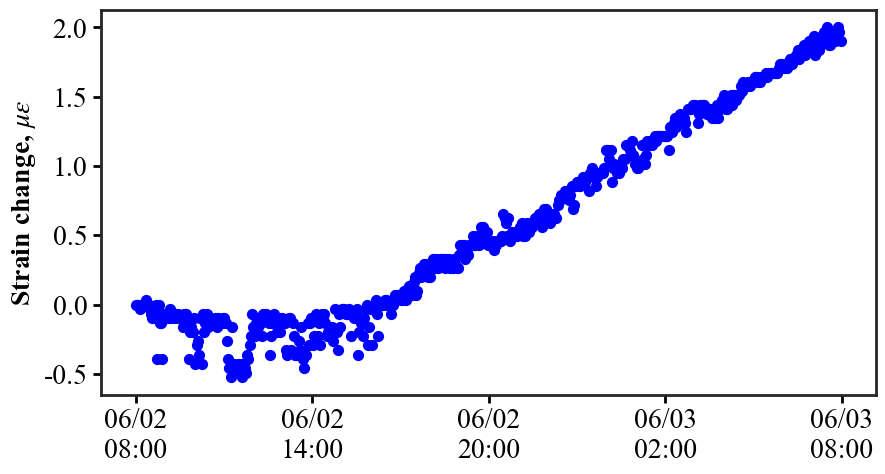

In [102]:
fig, ax = plt.subplots(figsize=(10,5))

#scatter plot
ax.scatter(t_sel, strian_sel, color='blue', s=50, label='Field Pressure Data')

ax.xaxis_date()
date_format = mdates.DateFormatter('%m/%d\n%H:%M')
ax.xaxis.set_major_formatter(date_format)

start = datetime.datetime(2022, 6, 2, 8, 0)
# end   = datetime.datetime(2022, 6, 2, 16, 0)
end   = datetime.datetime(2022, 6, 3, 8, 0)



ticks = pd.date_range(start, end, freq='6h')  # 每 4 小时一个
# ticks = pd.date_range(start, end, freq='2h')  # 每 4 小时一个

ax.set_xticks(ticks)
ax.set_ylabel(r"Strain change, $\mu\varepsilon$")

# 设置主刻度间隔为 1 小时
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))

# 给外侧轴留空间，避免被裁切
# fig.subplots_adjust(right=0.82)
# plt.savefig('frac_curves_S6.png', dpi=600, bbox_inches='tight')
plt.show()



## Evo7 strain change fitting

In [109]:
a = ((9.869233e-16)/(1e-3)*6894.757*3.2808**2) 

In [110]:
b = 0.0002637/86400.0

In [111]:
a /b

23.99747190566125

[strain-fit] k  = 2.050e+00 mD
[strain-fit] η  = 1.395e-01 ft^2/s
[strain-fit] A  = 18.92 με   (幅值 = α/E*(1-2ν)/(1-ν)*(p_i-p_1))
[strain-fit] R² = 0.9581


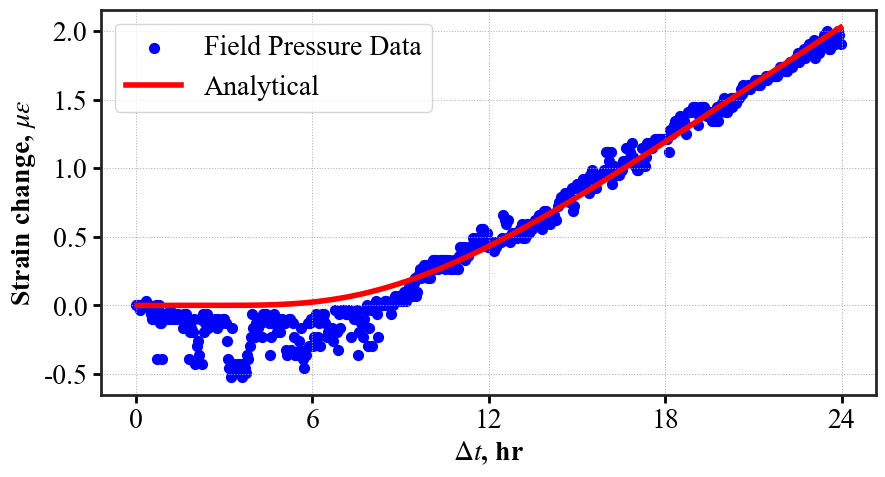

In [112]:
# ================== 只拟合 A 与 k 的简洁版（无 B、无 tau） ==================
from turtle import color
import numpy as np

# erfc 内核
try:
    from numpy import erfc as _erfc
except Exception:
    import math
    _erfc = np.vectorize(lambda z: 1.0 - math.erf(z))


def diffusivity_ft2_per_s(k_mD, mu_cP, phi, ct_per_psi):
    """k[mD], mu[cP], phi[-], ct[1/psi]  -> η[ft^2/s]"""
    k_m2 = k_mD * 9.869233e-16      # mD -> m^2
    mu_Pa_s = mu_cP * 1e-3          # cP -> Pa*s
    ct_per_Pa = ct_per_psi / 6894.757  # 1/psi -> 1/Pa
    eta_m2_s = k_m2 / (mu_Pa_s * phi * ct_per_Pa)
    eta_ft2_s = eta_m2_s * (3.280839895**2)
    return eta_ft2_s
    # return ((9.869233e-16)/(1e-3)*6894.757*3.2808**2) * k_mD / (mu_cP * phi * ct_per_psi)
    


# f_k(t) = erfc( dis / (2*sqrt(η*t)) )
def f_kernel(t_sec, k_mD, dis_ft, mu_cP, phi, ct_per_psi):
    t = np.asarray(t_sec, float)
    t = np.clip(t, 1e-9, None)  # 避免 t=0
    eta = diffusivity_ft2_per_s(k_mD, mu_cP, phi, ct_per_psi)
    z = dis_ft / (2.0 * np.sqrt(eta * t))
    return _erfc(z)

# 给定 k 的最优 A（解析最小二乘）
def A_opt_given_k(t_sec, y_vals, k_mD, dis_ft, mu_cP, phi, ct_per_psi, nonneg=True):
    f = f_kernel(t_sec, k_mD, dis_ft, mu_cP, phi, ct_per_psi)
    num = np.nansum(f * y_vals)
    den = np.nansum(f * f)
    if den <= 0:
        return 0.0
    A = num / den
    if nonneg:
        A = max(0.0, A)
    return float(A)

# SSE(log10 k)
def sse_of_logk(logk, t_sec, y_vals, dis_ft, mu_cP, phi, ct_per_psi):
    k = 10.0 ** logk
    A = A_opt_given_k(t_sec, y_vals, k, dis_ft, mu_cP, phi, ct_per_psi, nonneg=True)
    yhat = A * f_kernel(t_sec, k, dis_ft, mu_cP, phi, ct_per_psi)
    r = y_vals - yhat
    return float(np.nansum(r * r))

# 简单的一维黄金分割（log10 k 空间）
def golden_search_1d(fun, a, b, tol=1e-6, iters=80):
    phi = (1 + np.sqrt(5)) / 2
    invphi = 1 / phi
    c = b - invphi * (b - a)
    d = a + invphi * (b - a)
    fc, fd = fun(c), fun(d)
    for _ in range(iters):
        if (b - a) < tol:
            break
        if fc < fd:
            b, d, fd = d, c, fc
            c = b - invphi * (b - a)
            fc = fun(c)
        else:
            a, c, fc = c, d, fd
            d = a + invphi * (b - a)
            fd = fun(d)
    return (a + b) / 2.0

# 主拟合函数：只拟合 A（με）和 k（mD）
def fit_A_k_strain(t_sec, y_ueps, dis_ft, mu_cP, phi, ct_per_psi,
                   k_bounds=(1e-6, 1e3), return_curve=True):
    t = np.asarray(t_sec, float)
    y = np.asarray(y_ueps, float)
    m = np.isfinite(t) & np.isfinite(y) & (t > 0)
    t, y = t[m], y[m]
    if t.size < 5:
        raise ValueError("有效点太少，无法拟合。")

    # 粗网格锁区间
    lo, hi = np.log10(k_bounds[0]), np.log10(k_bounds[1])
    grid = np.linspace(lo, hi, 200)
    sse_vals = np.array([sse_of_logk(g, t, y, dis_ft, mu_cP, phi, ct_per_psi) for g in grid])
    j = int(np.argmin(sse_vals))
    a = grid[max(0, j-1)]
    b = grid[min(len(grid)-1, j+1)]
    if j == 0: a, b = lo, grid[3]
    if j == len(grid)-1: a, b = grid[-4], hi

    # 黄金分割精化
    logk_best = golden_search_1d(
        lambda lk: sse_of_logk(lk, t, y, dis_ft, mu_cP, phi, ct_per_psi), a, b,
        tol=1e-6, iters=80
    )
    k_best_mD = 10.0 ** logk_best
    A_best = A_opt_given_k(t, y, k_best_mD, dis_ft, mu_cP, phi, ct_per_psi, nonneg=True)
    yhat = A_best * f_kernel(t, k_best_mD, dis_ft, mu_cP, phi, ct_per_psi)

    # R^2
    ss_res = np.nansum((y - yhat)**2)
    ss_tot = np.nansum((y - np.nanmean(y))**2)
    R2 = 1.0 - ss_res/ss_tot if ss_tot > 0 else np.nan

    if return_curve:
        return k_best_mD, A_best, R2, (t, yhat)
    else:
        return k_best_mD, A_best, R2

# ================== 准备拟合所需 t(秒) 和 y(με) ==================
# 以可见窗口起点为 t=0
t0 = t_sel.iloc[0]
t_sec = (t_sel - t0).dt.total_seconds().to_numpy()
y_ueps = strian_sel.astype(float)  # 单位：με（microstrain）

# ================== 这里填写物性与几何（单位务必正确） ==================
dis_ft       = 250        # 纤维点到压力阶跃/裂缝面的法向距离 [ft]
mu_cP        = 0.185       # 黏度 [cP]
phi          = 0.30        # 孔隙度 [-]
ct_per_psi   = 1.94e-5     # 总压缩系数 [1/psi]

# ================== 执行拟合并叠加到现有散点图 ==================
k_best, A_best, R2, (t_used, yhat) = fit_A_k_strain(
    t_sec, y_ueps, dis_ft, mu_cP, phi, ct_per_psi,
    k_bounds=(1e-6, 1e3), return_curve=True
)
eta_best = diffusivity_ft2_per_s(k_best, mu_cP, phi, ct_per_psi)

print(f"[strain-fit] k  = {k_best:.3e} mD")
print(f"[strain-fit] η  = {eta_best:.3e} ft^2/s")
print(f"[strain-fit] A  = {A_best:.2f} με   (幅值 = α/E*(1-2ν)/(1-ν)*(p_i-p_1))")
print(f"[strain-fit] R² = {R2:.4f}")

# 叠加绘图
def _sec_to_hms(x, pos=None):
    h = int(x // 3600); m = int((x % 3600)//60); s = int(x % 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

fig2, ax2 = plt.subplots(figsize=(10,5))
ax2.scatter(t_sel, y_ueps, s=50, label='Field Pressure Data', color='blue')

t_used_dt = pd.to_datetime(t_used, unit='s', origin=t0)
ax2.plot(t_used_dt, yhat, lw=4, color='red',
         label='Analytical')
        #  label=f"fit: k={k_best:.2e} mD, A={A_best:.1f} με, R²={R2:.3f}")

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d\n%H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=4))
# ax2.xaxis.set_major_formatter(FuncFormatter(_sec_to_hms))
# ax2.set_xticks([0, 7200,  14400,  21600, 28800])
# ax2.set_xticklabels(['0','2','4','6','8'])
# ax2.set_xlabel(r'$\Delta t$, hr')

start = datetime.datetime(2022, 6, 2, 8, 0)
# end   = datetime.datetime(2022, 6, 2, 16, 0)
end   = datetime.datetime(2022, 6, 3, 8, 0)

# ticks = pd.date_range(start, end, freq='2h')  # 每 4 小时一个
ticks = pd.date_range(start, end, freq='6h')  # 每 4 小时一个

ax2.set_xticks(ticks)
# ax2.set_xticklabels(['0','2','4','6','8'])
ax2.set_xticklabels(['0','6','12','18','24'])
ax2.set_xlabel(r'$\Delta t$, hr')

ax2.set_ylabel(r"Strain change, $\mu\varepsilon$")
ax2.legend()
ax2.grid(True, which='both', linestyle=':', linewidth=0.75)
# plt.tight_layout()
plt.show()


## loop to find the peak near the pressure gauge MD

In [ ]:

def nearest_col_indices(depth_1d, targets):
    """
    targets 可以是标量或数组。返回与每个 target 最近的列索引。
    """
    t = np.atleast_1d(targets).astype(float)
    # 计算 |depth - target| 并在列轴上取最小
    idx = np.argmin(np.abs(depth_1d[None, :] - t[:, None]), axis=1)
    return idx

targets = gauge_to_fiber[1]

# targets = 13004
print("targets:", targets)
idx = nearest_col_indices(depth, targets)
depth_near = depth[idx]
err = targets - depth_near

print("targets:    ", targets)
print("idx:        ", idx)
print("depth_near: ", depth_near)
print("error(ft):  ", err)

ds = pd.to_datetime(pd.Series(date_str.astype(str)), format='%m/%d/%Y %H:%M:%S.%f')
# print(type(ds))
# print(ds)

#取部分数据进行绘图

# ---- 3) 设定你要显示的时间段（同一时区！）----
# start = pd.Timestamp("2022-06-02 08:00:00")
# end   = pd.Timestamp("2022-06-02 16:00:00")
# end   = pd.Timestamp("2022-06-03 08:00:00")

start = datetime.datetime(2022, 3, 15, 9, 0)
end = datetime.datetime(2022, 3, 15, 17, 0)
# end   = datetime.datetime(2022, 3, 21, 19, 0)



mask = (ds >= start) & (ds <= end)
# mask = np.ones(len(ds), dtype=bool)

t_sel    = ds[mask]
print(mask)

for i in range(-150 , -50 ):   # -50 到 +50
    idx_new = idx + i 
    cols = dstrain[:, idx_new]                 # shape = (N_time, len(targets)) 
    cols = -1 * cols
    # print("idx-i:", idx-i)
    # length = len(cols)
    # print(f"读取 {length} 条记录")
    # print("cols", cols)


    strian_sel    = cols[mask]
    strian_sel = strian_sel - strian_sel[0]  # 以起始点为零点
    fig, ax = plt.subplots(figsize=(10,5))

    #   scatter plot
    ax.scatter(t_sel, strian_sel, color='blue', s=50, label='Field Pressure Data')
    # ax.plot(t_sel, strian_sel, color='blue', lw = 2, label='Field Pressure Data')

    ax.xaxis_date()
    date_format = mdates.DateFormatter('%m/%d\n%H:%M')
    ax.xaxis.set_major_formatter(date_format)
    # 设置主刻度间隔为 1 小时
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    # ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    #图例显示index
    ax.set_title(f'Fiber Index: {idx_new}')



In [34]:
print("cols shape:", np.shape(cols))
print("mask shape:", np.shape(mask))
print("mask True count:", np.sum(mask))
print("cols head:", cols[:5] if len(cols)>0 else cols)

strian_sel = cols[mask]
print("strian_sel shape:", np.shape(strian_sel))


cols shape: (7008, 1)
mask shape: (7008,)
mask True count: 6153
cols head: [[ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [-0.04590164]]
strian_sel shape: (6153, 1)
